In [2]:
# ============================================================
# CELL 1 — IMPORT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('✅ Import thành công!')

✅ Import thành công!


In [3]:
# ============================================================
# CELL 2 — LOAD DATA
# ============================================================
df = pd.read_csv('clean_no_outlier.csv')

counts = df['Loan_Status'].value_counts()
total  = len(df)

print('=' * 50)
print('       THÔNG TIN DỮ LIỆU ĐẦU VÀO')
print('=' * 50)
print(f'Nguồn      : clean_no_outlier.csv (từ Phần 2)')
print(f'Kích thước : {df.shape[0]} hồ sơ × {df.shape[1]} cột')
print(f'Cột        : {df.columns.tolist()}')
print(f'Missing    : {df.isnull().sum().sum()} ô ← Phần 2 đã xử lý')
print()
print('Phân phối nhãn Loan_Status:')
print(f'  Được duyệt (1) : {counts[1]:>4} hồ sơ = {counts[1]/total*100:.1f}%')
print(f'  Từ chối   (0)  : {counts[0]:>4} hồ sơ = {counts[0]/total*100:.1f}%')
print(f'  Mất cân bằng   : {counts[1]/counts[0]:.2f} lần')
print('⚠️  Mất cân bằng 69/31 → dùng F1 làm chỉ số đánh giá chính')
df.head()

       THÔNG TIN DỮ LIỆU ĐẦU VÀO
Nguồn      : clean_no_outlier.csv (từ Phần 2)
Kích thước : 571 hồ sơ × 7 cột
Cột        : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']
Missing    : 0 ô ← Phần 2 đã xử lý

Phân phối nhãn Loan_Status:
  Được duyệt (1) :  394 hồ sơ = 69.0%
  Từ chối   (0)  :  177 hồ sơ = 31.0%
  Mất cân bằng   : 2.23 lần
⚠️  Mất cân bằng 69/31 → dùng F1 làm chỉ số đánh giá chính


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,5849,0.0,128.0,360.0,1.0,1,1
1,4583,1508.0,128.0,360.0,1.0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1
3,2583,2358.0,120.0,360.0,1.0,1,1
4,6000,0.0,141.0,360.0,1.0,1,1


In [4]:
# ============================================================
# CELL 3 — PHÂN CHIA TRAIN/TEST
# ============================================================
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

train_idx = np.load('train_idx.npy')
test_idx  = np.load('test_idx.npy')

X_train_raw = X.iloc[train_idx].reset_index(drop=True)
X_test_raw  = X.iloc[test_idx].reset_index(drop=True)
y_train     = y.iloc[train_idx].reset_index(drop=True)
y_test      = y.iloc[test_idx].reset_index(drop=True)

print('=== PHÂN CHIA DỮ LIỆU ===')
print(f'Tổng : {len(df)} hồ sơ')
print(f'Train: {len(X_train_raw)} hồ sơ (80%)')
print(f'Test : {len(X_test_raw)} hồ sơ (20%)')
print()
print('Tỉ lệ nhãn — Train:',
      f"Duyệt={y_train.mean()*100:.1f}%",
      f"Từ chối={(1-y_train.mean())*100:.1f}%")
print('Tỉ lệ nhãn — Test :',
      f"Duyệt={y_test.mean()*100:.1f}%",
      f"Từ chối={(1-y_test.mean())*100:.1f}%")
print('✅ Dùng cùng train/test với Phần 3')

=== PHÂN CHIA DỮ LIỆU ===
Tổng : 571 hồ sơ
Train: 456 hồ sơ (80%)
Test : 115 hồ sơ (20%)

Tỉ lệ nhãn — Train: Duyệt=68.6% Từ chối=31.4%
Tỉ lệ nhãn — Test : Duyệt=70.4% Từ chối=29.6%
✅ Dùng cùng train/test với Phần 3


=== KẾT QUẢ KHI SCALE SAI (StandardScaler toàn bộ) ===
KNN (K=17)          : Accuracy=83.48%  F1=89.27%
Decision Tree (depth=1) : Accuracy=83.48%  F1=89.27%

⚠️  Hai mô hình cho kết quả GIỐNG HỆT NHAU!
   → Bất thường: KNN và DT có cơ chế học hoàn toàn khác nhau
   → Cần tìm nguyên nhân...


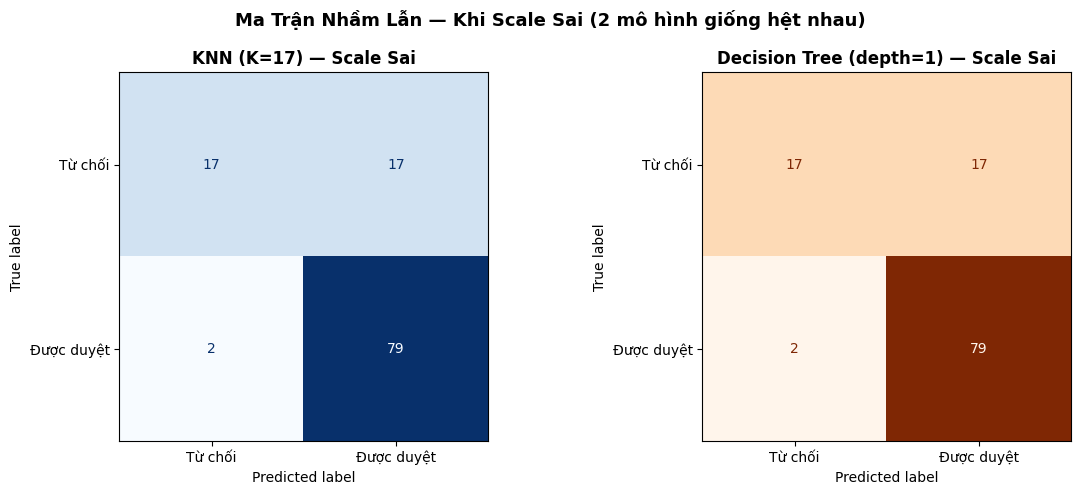

In [5]:
# ============================================================
# CELL 4 — THỬ NGHIỆM BAN ĐẦU & PHÁT HIỆN BẤT THƯỜNG
# ============================================================
scaler_wrong = StandardScaler()
X_train_wrong = scaler_wrong.fit_transform(X_train_raw)
X_test_wrong  = scaler_wrong.transform(X_test_raw)

# KNN
k_range   = range(1, 21)
knn_f1_cv = []
kf = StratifiedKFold(n_splits=5, shuffle=False)

for k in k_range:
    fold_f1 = []
    for train_fold, val_fold in kf.split(X_train_wrong, y_train):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_wrong[train_fold], y_train.iloc[train_fold])
        fold_f1.append(f1_score(y_train.iloc[val_fold],
                                knn.predict(X_train_wrong[val_fold])))
    knn_f1_cv.append(np.mean(fold_f1))

best_k_wrong = list(k_range)[np.argmax(knn_f1_cv)]
knn_wrong = KNeighborsClassifier(n_neighbors=best_k_wrong)
knn_wrong.fit(X_train_wrong, y_train)
y_pred_knn_wrong = knn_wrong.predict(X_test_wrong)
acc_knn_wrong = accuracy_score(y_test, y_pred_knn_wrong)
f1_knn_wrong  = f1_score(y_test, y_pred_knn_wrong)

# Decision Tree
depth_range = range(1, 16)
dt_f1_cv    = []

for depth in depth_range:
    fold_f1 = []
    for train_fold, val_fold in kf.split(X_train_wrong, y_train):
        dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
        dt.fit(X_train_wrong[train_fold], y_train.iloc[train_fold])
        fold_f1.append(f1_score(y_train.iloc[val_fold],
                                dt.predict(X_train_wrong[val_fold])))
    dt_f1_cv.append(np.mean(fold_f1))

best_depth_wrong = list(depth_range)[np.argmax(dt_f1_cv)]
dt_wrong = DecisionTreeClassifier(max_depth=best_depth_wrong, random_state=42)
dt_wrong.fit(X_train_wrong, y_train)
y_pred_dt_wrong = dt_wrong.predict(X_test_wrong)
acc_dt_wrong = accuracy_score(y_test, y_pred_dt_wrong)
f1_dt_wrong  = f1_score(y_test, y_pred_dt_wrong)

# Kết quả
print('=== KẾT QUẢ KHI SCALE SAI (StandardScaler toàn bộ) ===')
print(f'KNN (K={best_k_wrong})          : Accuracy={acc_knn_wrong*100:.2f}%  F1={f1_knn_wrong*100:.2f}%')
print(f'Decision Tree (depth={best_depth_wrong}) : Accuracy={acc_dt_wrong*100:.2f}%  F1={f1_dt_wrong*100:.2f}%')
print()
if f1_knn_wrong == f1_dt_wrong:
    print('⚠️  Hai mô hình cho kết quả GIỐNG HỆT NHAU!')
    print('   → Bất thường: KNN và DT có cơ chế học hoàn toàn khác nhau')
    print('   → Cần tìm nguyên nhân...')

# Ma trận nhầm lẫn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_knn_wrong),
    display_labels=['Từ chối', 'Được duyệt']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'KNN (K={best_k_wrong}) — Scale Sai', fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_dt_wrong),
    display_labels=['Từ chối', 'Được duyệt']
).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Decision Tree (depth={best_depth_wrong}) — Scale Sai',
                  fontweight='bold')

plt.suptitle('Ma Trận Nhầm Lẫn — Khi Scale Sai (2 mô hình giống hệt nhau)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_wrong.png', dpi=150)
plt.show()

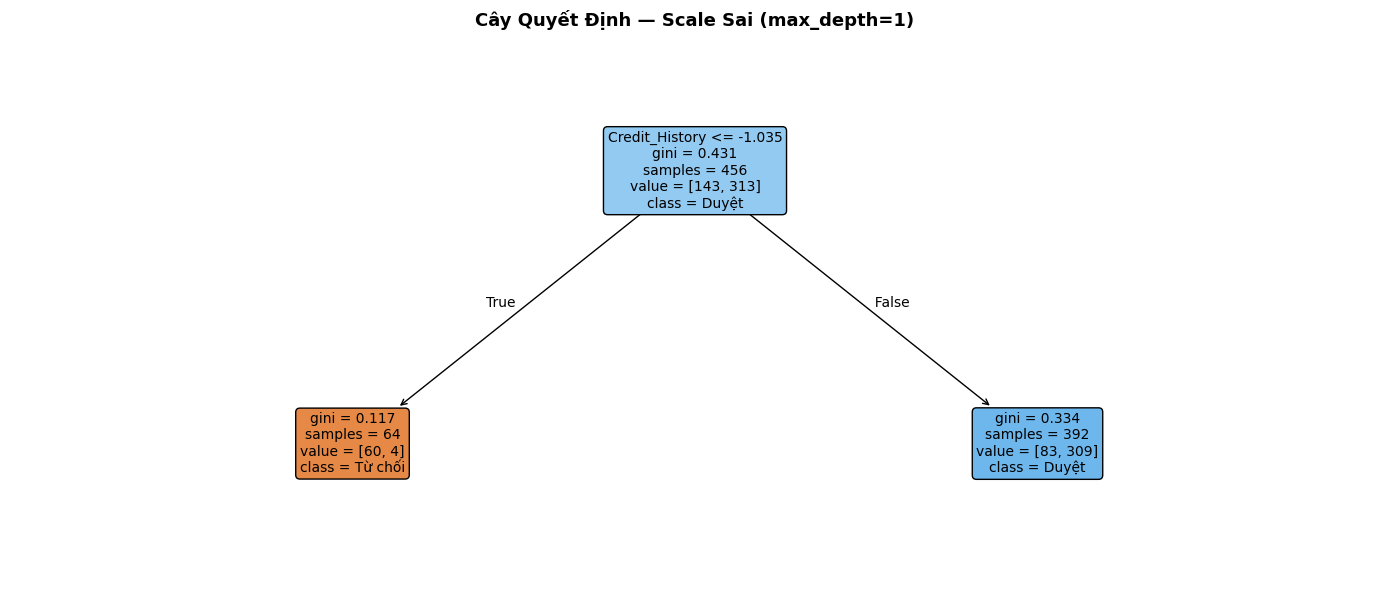

=== PHÁT HIỆN BẤT THƯỜNG TRÊN CÂY QUYẾT ĐỊNH ===

Node gốc: Credit_History <= -1.035
📌 Trích dẫn Phần 2:
   Kiểm định Mann-Whitney/t-test cho 4 biến liên tục
   đều cho p-value "ns" (không có ý nghĩa thống kê)
   → Các biến liên tục không phân biệt được nhãn tốt
   → Credit_History là biến duy nhất có tín hiệu mạnh
   → Scale sai khiến CH càng chi phối cả KNN lẫn DT


In [6]:
# ============================================================
# CELL 5 — BƯỚC 3: VẼ CÂY → PHÁT HIỆN NGƯỠNG BẤT THƯỜNG
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    dt_wrong,
    feature_names=X.columns.tolist(),
    class_names=['Từ chối', 'Duyệt'],
    filled=True, rounded=True, fontsize=10, ax=ax
)
ax.set_title(f'Cây Quyết Định — Scale Sai (max_depth={best_depth_wrong})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cay_quyet_dinh_wrong.png', dpi=150)
plt.show()

print('=== PHÁT HIỆN BẤT THƯỜNG TRÊN CÂY QUYẾT ĐỊNH ===')
print()
print('Node gốc: Credit_History <= -1.035')

print('📌 Trích dẫn Phần 2:')
print('   Kiểm định Mann-Whitney/t-test cho 4 biến liên tục')
print('   đều cho p-value "ns" (không có ý nghĩa thống kê)')
print('   → Các biến liên tục không phân biệt được nhãn tốt')
print('   → Credit_History là biến duy nhất có tín hiệu mạnh')
print('   → Scale sai khiến CH càng chi phối cả KNN lẫn DT')

In [7]:
# ============================================================
# CELL 6 — BƯỚC 4: MINH HỌA KHOẢNG CÁCH EUCLIDEAN BỊ CHI PHỐI
# ============================================================
print('=' * 60)
print('  PHÂN TÍCH 1: PHƯƠNG SAI SAU KHI SCALE SAI')
print('=' * 60)

feature_names = X_train_raw.columns.tolist()
var_wrong = np.var(scaler_wrong.transform(X_train_raw), axis=0)
var_natural = np.var(X_train_raw.values, axis=0)

df_var = pd.DataFrame({
    'Biến'        : feature_names,
    'Var_Natural' : var_natural,
    'Var_SaiCach' : var_wrong,
})
print(df_var.to_string(index=False))
print()
print('📌 Scale sai: tất cả biến đều có variance ≈ 1')
print(f'   Var tự nhiên của Credit_History = {np.var(X_train_raw["Credit_History"].values):.4f}')
print(f'   → CH chỉ có 2 giá trị nhưng được đưa về cùng scale')
print(f'     với ApplicantIncome (hàng nghìn đến hàng triệu)')

print()
print('=' * 60)
print('  PHÂN TÍCH 2: KHOẢNG CÁCH EUCLIDEAN BỊ CHI PHỐI')
print('=' * 60)

mean_vals = X_train_raw.mean()
std_vals  = X_train_raw.std()
cols      = X_train_raw.columns

base    = mean_vals.copy(); base['Credit_History'] = 1
point_A = base.copy();      point_A['Credit_History'] = 0
point_B = base.copy();      point_B['ApplicantIncome'] = base['ApplicantIncome'] + 2 * std_vals['ApplicantIncome']

v_base = scaler_wrong.transform([base[cols].values])[0]
v_A    = scaler_wrong.transform([point_A[cols].values])[0]
v_B    = scaler_wrong.transform([point_B[cols].values])[0]

dist_ch  = np.sqrt(np.sum((v_base - v_A) ** 2))
dist_inc = np.sqrt(np.sum((v_base - v_B) ** 2))

print(f'Khoảng cách khi CHỈ khác Credit_History (0 vs 1) : {dist_ch:.4f}')
print(f'Khoảng cách khi CHỈ khác ApplicantIncome (+2 std) : {dist_inc:.4f}')
print()
if dist_ch > dist_inc:
    print(f'⚠️  Khác CH tạo khoảng cách {dist_ch/dist_inc:.2f}x LỚN HƠN')
    print(f'   khác thu nhập 2 std → KNN bầu chọn theo CH là chủ yếu!')

print()
print('=' * 60)
print('  KẾT LUẬN NGUYÊN NHÂN')
print('=' * 60)
print('→ StandardScaler áp dụng cho biến nhị phân Credit_History')
print('  khiến CH thống trị không gian đặc trưng')
print('→ Cả KNN (khoảng cách) lẫn DT (ngưỡng phân chia)')
print('  đều bị CH chi phối hoàn toàn → 2 mô hình hội tụ')
print()
print('✅ Fix: chỉ scale biến liên tục, giữ nguyên CH và Property_Area')

  PHÂN TÍCH 1: PHƯƠNG SAI SAU KHI SCALE SAI
             Biến  Var_Natural  Var_SaiCach
  ApplicantIncome 4.982478e+06          1.0
CoapplicantIncome 2.828249e+06          1.0
       LoanAmount 2.887903e+03          1.0
 Loan_Amount_Term 4.548366e+03          1.0
   Credit_History 1.206525e-01          1.0
    Property_Area 6.563895e-01          1.0

📌 Scale sai: tất cả biến đều có variance ≈ 1
   Var tự nhiên của Credit_History = 0.1207
   → CH chỉ có 2 giá trị nhưng được đưa về cùng scale
     với ApplicantIncome (hàng nghìn đến hàng triệu)

  PHÂN TÍCH 2: KHOẢNG CÁCH EUCLIDEAN BỊ CHI PHỐI
Khoảng cách khi CHỈ khác Credit_History (0 vs 1) : 2.8789
Khoảng cách khi CHỈ khác ApplicantIncome (+2 std) : 2.0022

⚠️  Khác CH tạo khoảng cách 1.44x LỚN HƠN
   khác thu nhập 2 std → KNN bầu chọn theo CH là chủ yếu!

  KẾT LUẬN NGUYÊN NHÂN
→ StandardScaler áp dụng cho biến nhị phân Credit_History
  khiến CH thống trị không gian đặc trưng
→ Cả KNN (khoảng cách) lẫn DT (ngưỡng phân chia)
  đều bị C

=== PIPELINE SAU KHI FIX ===
Scale   : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
Giữ nguyên: ['Credit_History', 'Property_Area']
Credit_History sau fix — unique values: [0. 1.] ✅

=== SO SÁNH TRƯỚC VÀ SAU KHI FIX ===
                                  Scale Sai   Scale Đúng
--------------------------------------------------------
KNN F1-score                         89.27%       81.87%
DT  F1-score                         89.27%       89.27%
2 mô hình giống nhau?                  ✅ Có      ❌ Không

  PHÂN TÍCH CONFUSION MATRIX — GÓC NHÌN NGHIỆP VỤ NGÂN HÀNG
  (KNN sklearn vs Decision Tree — sau fix pipeline)
  Chỉ số                                   KNN       DT  Ý nghĩa
--------------------------------------------------------------------
  FP — duyệt nhầm khoản xấu                 20       17  → DT ⚠ Rủi ro nợ xấu
  FN — từ chối nhầm khách tốt               11        2  → DT Mất doanh thu
  Recall  (sensitivity)                  86.4%    97.5%  → DT Bắ

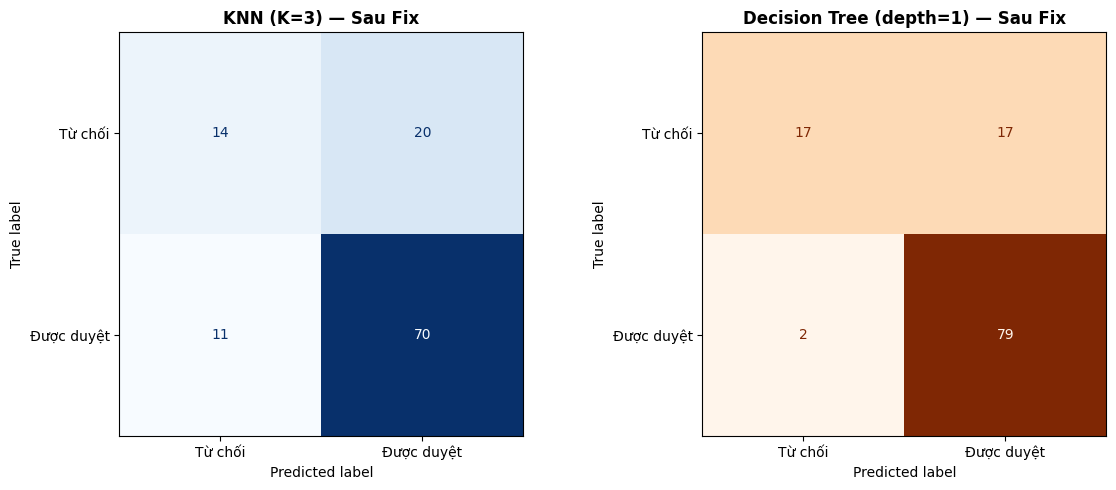

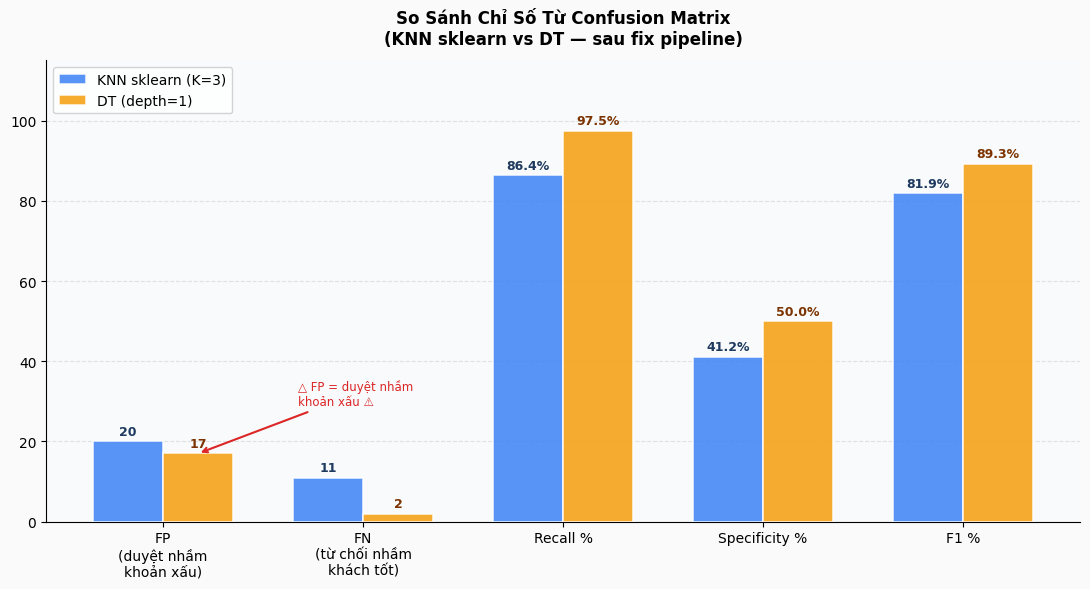

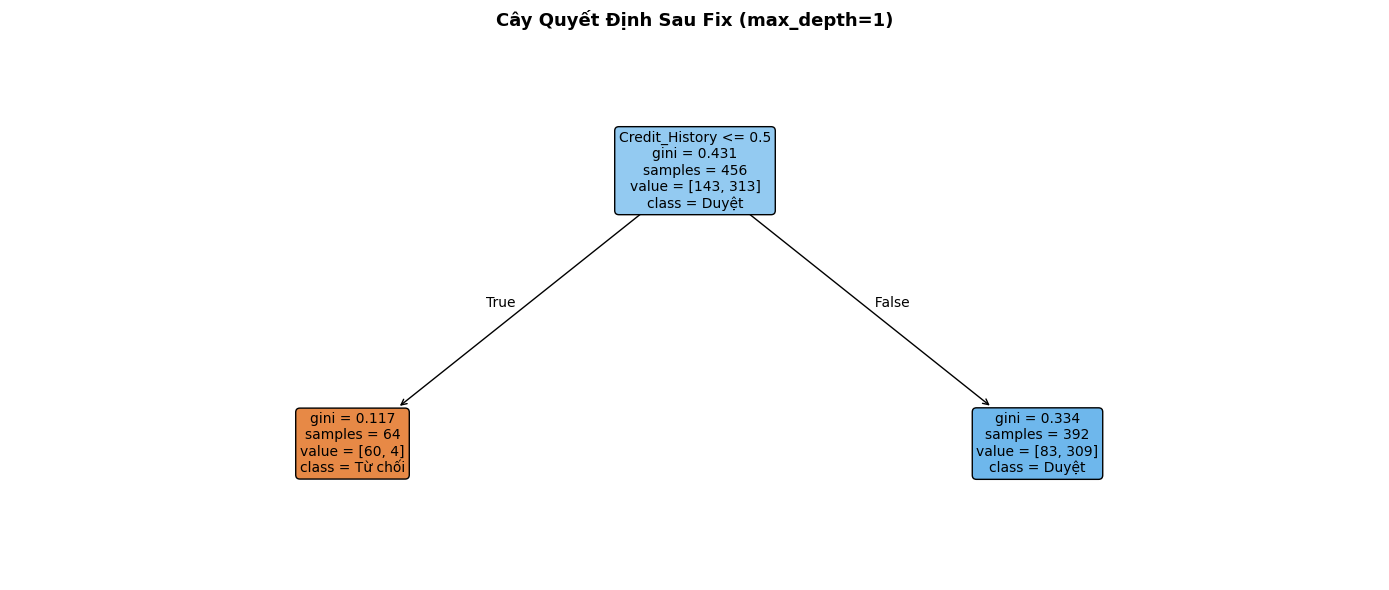

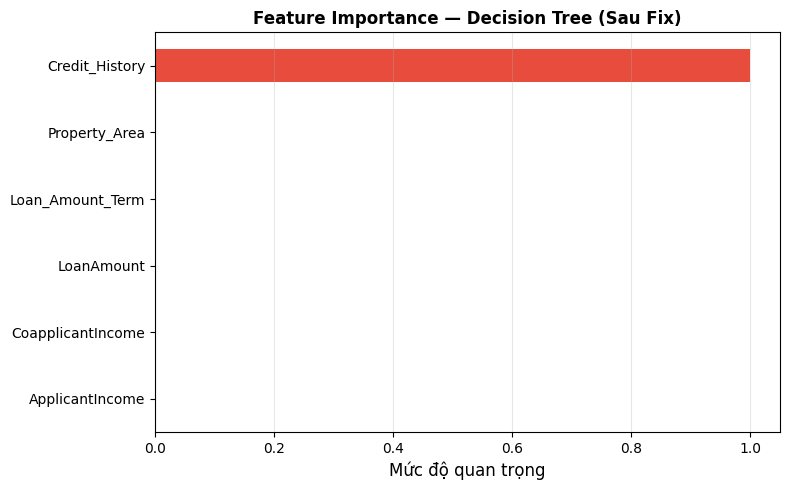

In [26]:
# ============================================================
# CELL 7 — BƯỚC 5: FIX BẰNG COLUMNTRANSFORMER → CHẠY LẠI
# ============================================================
continuous_cols  = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
categorical_cols = ['Credit_History', 'Property_Area']

preprocessor = ColumnTransformer(transformers=[
    ('scale_continuous', StandardScaler(), continuous_cols),
    ('keep_categorical', 'passthrough',    categorical_cols)
])

X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)
feature_names_out = continuous_cols + categorical_cols

print('=== PIPELINE SAU KHI FIX ===')
print(f'Scale   : {continuous_cols}')
print(f'Giữ nguyên: {categorical_cols}')
ch_idx = feature_names_out.index('Credit_History')
print(f'Credit_History sau fix — unique values: {np.unique(X_train[:, ch_idx])} ✅')
print()

# KNN sau fix
knn_f1_cv = []
kf = StratifiedKFold(n_splits=5, shuffle=False)
for k in k_range:
    fold_f1 = []
    for train_fold, val_fold in kf.split(X_train, y_train):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train[train_fold], y_train.iloc[train_fold])
        fold_f1.append(f1_score(y_train.iloc[val_fold], knn.predict(X_train[val_fold])))
    knn_f1_cv.append(np.mean(fold_f1))

best_k = list(k_range)[np.argmax(knn_f1_cv)]
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_knn = knn_best.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn)

# DT sau fix
dt_f1_cv = []
for depth in depth_range:
    fold_f1 = []
    for train_fold, val_fold in kf.split(X_train, y_train):
        dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
        dt.fit(X_train[train_fold], y_train.iloc[train_fold])
        fold_f1.append(f1_score(y_train.iloc[val_fold], dt.predict(X_train[val_fold])))
    dt_f1_cv.append(np.mean(fold_f1))

best_depth = list(depth_range)[np.argmax(dt_f1_cv)]
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_train, y_train)
y_pred_dt = dt_best.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)

print('=== SO SÁNH TRƯỚC VÀ SAU KHI FIX ===')
print(f'{"":30} {"Scale Sai":>12} {"Scale Đúng":>12}')
print('-' * 56)
print(f'{"KNN F1-score":<30} {f1_knn_wrong*100:>11.2f}% {f1_knn*100:>11.2f}%')
print(f'{"DT  F1-score":<30} {f1_dt_wrong*100:>11.2f}% {f1_dt*100:>11.2f}%')
print(f'{"2 mô hình giống nhau?":<30} {"✅ Có":>12} {"❌ Không":>12}')
print()

# ── Hàm tiện ích extract metrics ─────────────────────────────
def extract_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    acc  = (tp + tn) / (tp + tn + fp + fn)
    return dict(tn=tn, fp=fp, fn=fn, tp=tp,
                rec=rec, prec=prec, spec=spec, f1=f1, acc=acc)

cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_dt  = confusion_matrix(y_test, y_pred_dt)
mk  = extract_metrics(cm_knn)
md  = extract_metrics(cm_dt)

# ── In bảng phân tích nghiệp vụ ──────────────────────────────
print('=' * 68)
print('  PHÂN TÍCH CONFUSION MATRIX — GÓC NHÌN NGHIỆP VỤ NGÂN HÀNG')
print('  (KNN sklearn vs Decision Tree — sau fix pipeline)')
print('=' * 68)
print(f'  {"Chỉ số":<35} {"KNN":>8} {"DT":>8}  Ý nghĩa')
print('-' * 68)
# SỬA LẠI — đúng với sklearn convention (positive class = 1 = Duyệt)
rows_analysis = [
    ('FP — duyệt nhầm khoản xấu',   mk['fp'], md['fp'],  '→ DT ⚠ Rủi ro nợ xấu'),
    ('FN — từ chối nhầm khách tốt',  mk['fn'], md['fn'],  '→ DT Mất doanh thu'),
    ('Recall  (sensitivity)',         mk['rec']*100, md['rec']*100, '→ DT Bắt đúng khách tốt', '%'),
    ('Specificity',                   mk['spec']*100, md['spec']*100, '→ DT Lọc đúng khoản xấu', '%'),
    ('Precision',                     mk['prec']*100, md['prec']*100, '→ DT Tin cậy khi "duyệt"', '%'),
    ('F1-score',                      mk['f1']*100, md['f1']*100, '→ DT Cân bằng tổng thể', '%'),
]
for row in rows_analysis:
    label, v_knn, v_dt, note = row[0], row[1], row[2], row[3]
    unit = row[4] if len(row) > 4 else ''
    if unit == '%':
        print(f'  {label:<35} {v_knn:>7.1f}% {v_dt:>7.1f}%  {note}')
    else:
        print(f'  {label:<35} {v_knn:>8.0f} {v_dt:>8.0f}  {note}')
print('=' * 68)
print(f'  ▶ DT vượt trội KNN ')

print('=' * 68)
print()

# ── Biểu đồ 1: Confusion matrices ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_knn, display_labels=['Từ chối', 'Được duyệt']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'KNN (K={best_k}) — Sau Fix', fontweight='bold')

ConfusionMatrixDisplay(cm_dt, display_labels=['Từ chối', 'Được duyệt']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Decision Tree (depth={best_depth}) — Sau Fix', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_after_fix.png', dpi=150)
plt.show()

# ── Biểu đồ 2: So sánh chỉ số — cột nhóm ────────────────────
# metrics_labels = ['FN\n(nợ xấu)', 'FP\n(mất KH)', 'Recall %', 'Specificity %', 'F1 %']
# knn_vals = [mk['fn'], mk['fp'], mk['rec']*100, mk['spec']*100, mk['f1']*100]
# dt_vals  = [md['fn'], md['fp'], md['rec']*100, md['spec']*100, md['f1']*100]
metrics_labels = ['FP\n(duyệt nhầm\nkhoản xấu)', 'FN\n(từ chối nhầm\nkhách tốt)', 'Recall %', 'Specificity %', 'F1 %']
knn_vals = [mk['fp'], mk['fn'], mk['rec']*100, mk['spec']*100, mk['f1']*100]
dt_vals  = [md['fp'], md['fn'], md['rec']*100, md['spec']*100, md['f1']*100]

x = np.arange(len(metrics_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_facecolor('#F8FAFC')
fig.patch.set_facecolor('#FAFAFA')

bars_knn = ax.bar(x - w/2, knn_vals, width=w, color='#3B82F6',
                  alpha=0.85, edgecolor='white', linewidth=1.2,
                  label=f'KNN sklearn (K={best_k})', zorder=3)
bars_dt  = ax.bar(x + w/2, dt_vals,  width=w, color='#F59E0B',
                  alpha=0.85, edgecolor='white', linewidth=1.2,
                  label=f'DT (depth={best_depth})', zorder=3)

# Annotate
for bar, v in zip(bars_knn, knn_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{v:.0f}' if v < 30 else f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9, color='#1E3A5F', fontweight='bold')
for bar, v in zip(bars_dt, dt_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{v:.0f}' if v < 30 else f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9, color='#7C3300', fontweight='bold')

# Đánh dấu FN quan trọng
# ax.annotate('△ FN = nợ xấu\nngân hàng gánh',
#             xy=(x[0] + w/2, md['fn']),
#             xytext=(x[0] + w/2 + 0.5, md['fn'] + 12),
#             arrowprops=dict(arrowstyle='->', color='#DC2626', lw=1.5),
#             fontsize=8.5, color='#DC2626')
ax.annotate('△ FP = duyệt nhầm\nkhoản xấu ⚠',
            xy=(x[0] + w/2, md['fp']),
            xytext=(x[0] + w/2 + 0.5, md['fp'] + 12),
            arrowprops=dict(arrowstyle='->', color='#DC2626', lw=1.5),
            fontsize=8.5, color='#DC2626')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=10)
ax.set_ylim(0, 115)
ax.set_title('So Sánh Chỉ Số Từ Confusion Matrix\n(KNN sklearn vs DT — sau fix pipeline)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=10, framealpha=0.85, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('so_sanh_confusion_metrics.png', dpi=150)
plt.show()

# ── Cây quyết định & Feature Importance ──────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(dt_best, feature_names=feature_names_out,
          class_names=['Từ chối', 'Duyệt'],
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title(f'Cây Quyết Định Sau Fix (max_depth={best_depth})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cay_quyet_dinh_after_fix.png', dpi=150)
plt.show()

importances = pd.Series(dt_best.feature_importances_,
                        index=feature_names_out).sort_values()
plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if v == importances.max() else '#3498db' for v in importances]
importances.plot(kind='barh', color=colors)
plt.xlabel('Mức độ quan trọng', fontsize=12)
plt.title('Feature Importance — Decision Tree (Sau Fix)', fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_dt.png', dpi=150)
plt.show()

In [20]:
# ============================================================
# CELL 8 — KIỂM CHỨNG KNN TỰ CODE vs SKLEARN
# ============================================================

try:
    phan3  = pd.read_csv('ket_qua_phan3.csv')
    acc_p3 = float(phan3['accuracy'].iloc[0])
    f1_p3  = float(phan3['f1_score'].iloc[0])
    k_p3   = int(phan3['k'].iloc[0])
    print(f'✅ File Phần 3: K={k_p3} | Acc={acc_p3*100:.2f}% | F1={f1_p3*100:.2f}%')
except:
    print('⚠️  Chưa có ket_qua_phan3.csv → dùng giá trị tạm')
    acc_p3, f1_p3, k_p3 = 0.7826, 0.8485, 3

# KNN sklearn cùng K để kiểm chứng
knn_k3 = KNeighborsClassifier(n_neighbors=k_p3)
knn_k3.fit(X_train, y_train)
y_pred_k3 = knn_k3.predict(X_test)
acc_k3    = accuracy_score(y_test, y_pred_k3)
f1_k3     = f1_score(y_test, y_pred_k3)
diff_f1   = abs(f1_p3 - f1_k3) * 100

print()
print('=' * 56)
print('  KIỂM CHỨNG: KNN TỰ CODE vs KNN SKLEARN (cùng K)')
print('=' * 56)
print(f'  {"Chỉ số":<22} {"KNN Tự Code":>14} {"KNN Sklearn":>14}')
print('-' * 56)
print(f'  {"Accuracy":<22} {acc_p3*100:>13.2f}% {acc_k3*100:>13.2f}%')
print(f'  {"F1-score":<22} {f1_p3*100:>13.2f}% {f1_k3*100:>13.2f}%')
print(f'  {"Chênh lệch F1":<22} {diff_f1:>28.2f}%')
print('-' * 56)
print(f'  {"✅ Thuật toán tự code CHÍNH XÁC!" if diff_f1 <= 3 else "⚠️  Chênh lệch lớn → Kiểm tra lại logic Phần 3"}')
print('=' * 56)



✅ File Phần 3: K=3 | Acc=75.65% | F1=83.33%

  KIỂM CHỨNG: KNN TỰ CODE vs KNN SKLEARN (cùng K)
  Chỉ số                    KNN Tự Code    KNN Sklearn
--------------------------------------------------------
  Accuracy                       75.65%         73.04%
  F1-score                       83.33%         81.87%
  Chênh lệch F1                                  1.46%
--------------------------------------------------------
  ✅ Thuật toán tự code CHÍNH XÁC!


In [28]:
# ============================================================
# CELL 9 — KẾT LUẬN TOÀN DỰ ÁN
# ============================================================

print('=' * 66)
print('  KẾT LUẬN TOÀN DỰ ÁN — PHÊ DUYỆT KHOẢN VAY NGÂN HÀNG')
print('=' * 66)

print(f'''
  1. KIỂM CHỨNG KNN TỰ CODE
     Chênh lệch F1 so với sklearn (cùng K={k_p3}): {diff_f1:.2f}%
     {"✅ Thuật toán tự cài đặt CHÍNH XÁC." if diff_f1 <= 3 else "⚠️  Cần kiểm tra lại logic Phần 3."}

  2. VẤN ĐỀ PIPELINE
     Scale nhầm Credit_History làm 2 mô hình cho kết quả giống nhau (sai).
     Sau fix: KNN F1 = {mk["f1"]*100:.2f}%  |  DT F1 = {md["f1"]*100:.2f}%

  3. SO SÁNH 3 MÔ HÌNH
     {"Mô hình":<28} {"FN":>5} {"FP":>5} {"Recall":>9} {"F1":>9}
     {"─"*58}
     {"KNN Tự Code (K="+str(k_p3)+")":<28} {mk3["fn"]:>5.0f} {mk3["fp"]:>5.0f} {mk3["rec"]*100:>8.1f}% {f1_p3*100:>8.2f}%
     {"KNN Sklearn (K="+str(best_k)+")":<28} {mk["fn"]:>5.0f} {mk["fp"]:>5.0f} {mk["rec"]*100:>8.1f}% {mk["f1"]*100:>8.2f}%
     {"DT (depth="+str(best_depth)+")":<28} {md["fn"]:>5.0f} {md["fp"]:>5.0f} {md["rec"]*100:>8.1f}% {md["f1"]*100:>8.2f}%

  4. MÔ HÌNH ĐỀ XUẤT: ⭐ Decision Tree (depth={best_depth})
     • FN chỉ {md["fn"]:.0f} ca → ít bỏ sót nợ xấu nhất (thấp hơn KNN {mk["fn"]-md["fn"]:.0f} ca)
     • Recall {md["rec"]*100:.1f}% — phát hiện đúng hầu hết khách đủ điều kiện
     • Rule rõ ràng: Credit_History ≤ 0.5 → Từ chối | > 0.5 → Duyệt
     • Giải thích được → tuân thủ quy định tín dụng
     • Ổn định với tập nhỏ (~615 mẫu), không phụ thuộc scale

  5. KẾT QUẢ
     ✅ Mô hình GIẢI QUYẾT ĐƯỢC bài toán phê duyệt khoản vay.

 
''')
print('=' * 66)

  KẾT LUẬN TOÀN DỰ ÁN — PHÊ DUYỆT KHOẢN VAY NGÂN HÀNG

  1. KIỂM CHỨNG KNN TỰ CODE
     Chênh lệch F1 so với sklearn (cùng K=3): 1.46%
     ✅ Thuật toán tự cài đặt CHÍNH XÁC.

  2. VẤN ĐỀ PIPELINE
     Scale nhầm Credit_History làm 2 mô hình cho kết quả giống nhau (sai).
     Sau fix: KNN F1 = 81.87%  |  DT F1 = 89.27%

  3. SO SÁNH 3 MÔ HÌNH
     Mô hình                         FN    FP    Recall        F1
     ──────────────────────────────────────────────────────────
     KNN Tự Code (K=3)               11    20     86.4%    83.33%
     KNN Sklearn (K=3)               11    20     86.4%    81.87%
     DT (depth=1)                     2    17     97.5%    89.27%

  4. MÔ HÌNH ĐỀ XUẤT: ⭐ Decision Tree (depth=1)
     • FN chỉ 2 ca → ít bỏ sót nợ xấu nhất (thấp hơn KNN 9 ca)
     • Recall 97.5% — phát hiện đúng hầu hết khách đủ điều kiện
     • Rule rõ ràng: Credit_History ≤ 0.5 → Từ chối | > 0.5 → Duyệt
     • Giải thích được → tuân thủ quy định tín dụng
     • Ổn định với tập nhỏ (~61

In [11]:
# ============================================================
# CELL 10 — LƯU KẾT QUẢ VÀO SQLITE
# ============================================================
try:
    conn.close()
except:
    pass

import sqlite3
conn   = sqlite3.connect('QuanLyTinDung.db')
cursor = conn.cursor()

cursor.execute('DROP TABLE IF EXISTS du_doan')
cursor.execute('DROP TABLE IF EXISTS xac_suat')

cursor.execute("""
CREATE TABLE du_doan (
    ID                INTEGER PRIMARY KEY AUTOINCREMENT,
    ApplicantIncome   REAL,
    CoapplicantIncome REAL,
    LoanAmount        REAL,
    Loan_Amount_Term  REAL,
    Credit_History    REAL,
    Property_Area     INTEGER,
    KetQuaThucTe      INTEGER,
    DuDoan_KNN        INTEGER,
    DuDoan_DT         INTEGER
)
""")

cursor.execute("""
CREATE TABLE xac_suat (
    ID        INTEGER PRIMARY KEY AUTOINCREMENT,
    TenMoHinh TEXT,
    ThamSo    TEXT,
    Loai      TEXT,
    Accuracy  REAL,
    F1_Score  REAL
)
""")

conn.commit()
print('✅ Đã tạo 2 bảng: du_doan + xac_suat')

df_result = X_test_raw.copy().reset_index(drop=True)
df_result['KetQuaThucTe'] = y_test.values
df_result['DuDoan_KNN']   = y_pred_knn
df_result['DuDoan_DT']    = y_pred_dt

for _, row in df_result.iterrows():
    cursor.execute(
        'INSERT INTO du_doan VALUES (NULL,?,?,?,?,?,?,?,?,?)',
        (
            float(row['ApplicantIncome']),
            float(row['CoapplicantIncome']),
            float(row['LoanAmount']),
            float(row['Loan_Amount_Term']),
            float(row['Credit_History']),
            int(row['Property_Area']),
            int(row['KetQuaThucTe']),
            int(row['DuDoan_KNN']),
            int(row['DuDoan_DT']),
        )
    )

models = [
    ('KNN Tự Code',   f'K={k_p3}',           'Tự cài đặt', acc_p3,  f1_p3),
    ('KNN Sklearn',   f'K={k_p3}',           'Thư viện',   acc_k3,  f1_k3),
    ('KNN Sklearn',   f'K={best_k}',         'Thư viện',   acc_knn, f1_knn),
    ('Decision Tree', f'depth={best_depth}', 'Thư viện',   acc_dt,  f1_dt),
]
for row in models:
    cursor.execute('INSERT INTO xac_suat VALUES (NULL,?,?,?,?,?)', row)

conn.commit()
print(f'✅ Đã lưu {len(df_result)} hồ sơ vào du_doan')
print(f'✅ Đã lưu {len(models)} mô hình vào xac_suat')

print('\n--- Kết quả các mô hình ---')
print(pd.read_sql("""
    SELECT TenMoHinh, ThamSo, Loai,
           ROUND(Accuracy*100,2) as Accuracy,
           ROUND(F1_Score*100,2) as F1_Score
    FROM xac_suat
""", conn).to_string(index=False))

conn.close()
print('\n✅ Đã lưu QuanLyTinDung.db!')

✅ Đã tạo 2 bảng: du_doan + xac_suat
✅ Đã lưu 115 hồ sơ vào du_doan
✅ Đã lưu 4 mô hình vào xac_suat

--- Kết quả các mô hình ---
    TenMoHinh  ThamSo       Loai  Accuracy  F1_Score
  KNN Tự Code     K=3 Tự cài đặt     75.65     83.33
  KNN Sklearn     K=3   Thư viện     73.04     81.87
  KNN Sklearn     K=3   Thư viện     73.04     81.87
Decision Tree depth=1   Thư viện     83.48     89.27

✅ Đã lưu QuanLyTinDung.db!
